# =======================================================
# TALLER EN CLASE
## Análisis e Interpretación de Datos A través de Python
### Abril 17 de 2016
# =======================================================


In [1]:
# Instalar si hace falta:
# pip install requests beautifulsoup4 pandas scikit-learn matplotlib seaborn wordcloud

import re
import string
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup
from urllib.parse import urljoin
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from wordcloud import WordCloud

# ------------------------------------------------------------
## a) WEB SCRAPING: extraer títulos y precios
# ------------------------------------------------------------

In [2]:

BASE_URL = "http://books.toscrape.com/"
START_URL = urljoin(BASE_URL, "catalogue/page-1.html")

HEADERS = {
    "User-Agent": "Mozilla/5.0"
}

def scrape_books(start_url):
    books = []
    url = start_url

    while url:
        response = requests.get(url, headers=HEADERS, timeout=20)
        response.raise_for_status()

        soup = BeautifulSoup(response.text, "html.parser")

        for article in soup.select("article.product_pod"):
            title = article.h3.a["title"].strip()
            price_text = article.select_one("p.price_color").get_text(strip=True)

            # Extraer solo el número del precio
            price = float(re.sub(r"[^\d.]", "", price_text))

            books.append({
                "title": title,
                "price": price
            })

        next_btn = soup.select_one("li.next > a")
        if next_btn:
            url = urljoin(url, next_btn["href"])
        else:
            url = None

    return pd.DataFrame(books)

datos = scrape_books(START_URL)

print("Primeras filas de la base original:")
print(datos.head())
print("\nNúmero total de libros:", len(datos))

# Guardar base original
datos.to_csv("datos_scraping_libros.csv", index=False)

Primeras filas de la base original:
                                   title  price
0                   A Light in the Attic  51.77
1                     Tipping the Velvet  53.74
2                             Soumission  50.10
3                          Sharp Objects  47.82
4  Sapiens: A Brief History of Humankind  54.23

Número total de libros: 1000


# ------------------------------------------------------------
## b) LIMPIEZA DEL TEXTO EN LOS TÍTULOS
### - pasar a minúsculas
### - eliminar números
### - eliminar caracteres especiales
### - remover stopwords
### ------------------------------------------------------------

In [3]:

stop_words = set(ENGLISH_STOP_WORDS)

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r"\d+", " ", texto)                         # eliminar números
    texto = re.sub(rf"[{re.escape(string.punctuation)}]", " ", texto)  # eliminar puntuación
    texto = re.sub(r"[^a-z\s]", " ", texto)                   # dejar solo letras y espacios
    texto = re.sub(r"\s+", " ", texto).strip()                # espacios extra

    tokens = [palabra for palabra in texto.split() if palabra not in stop_words]

    return " ".join(tokens)

datos_limpios = datos.copy()
datos_limpios["title_clean"] = datos_limpios["title"].apply(limpiar_texto)

print("\nBase con títulos limpios:")
print(datos_limpios.head())

datos_limpios.to_csv("datos_limpios.csv", index=False)



Base con títulos limpios:
                                   title  price  \
0                   A Light in the Attic  51.77   
1                     Tipping the Velvet  53.74   
2                             Soumission  50.10   
3                          Sharp Objects  47.82   
4  Sapiens: A Brief History of Humankind  54.23   

                       title_clean  
0                      light attic  
1                   tipping velvet  
2                       soumission  
3                    sharp objects  
4  sapiens brief history humankind  


# ------------------------------------------------------------
## c) BASE "count" CON N-GRAMAS Y FRECUENCIAS + NUBE DE PALABRAS
# ------------------------------------------------------------

### Puedes cambiar esto:
### (1,1) = unigramas
### (2,2) = bigramas
### (1,2) = unigramas y bigramas


Base count:
      ngram  frecuencia
0       vol          45
1      life          39
2      girl          30
3      love          30
4     world          24
5       art          21
6     story          19
7       new          19
8   recipes          17
9     guide          16
10   fruits          16
11   basket          16
12  history          16
13   little          14
14  america          13
15     city          13
16   volume          12
17   potter          12
18      god          12
19     book          12


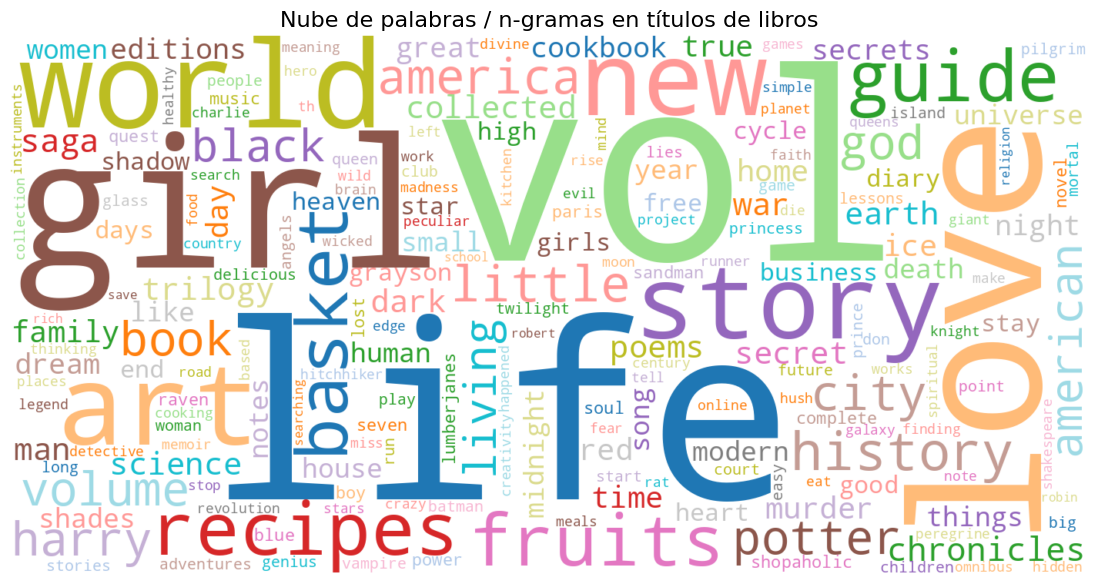

In [9]:

NGRAM_RANGE = (1, 1)

vectorizer_count = CountVectorizer(ngram_range=NGRAM_RANGE)
X_count = vectorizer_count.fit_transform(datos_limpios["title_clean"])

count = pd.DataFrame({
    "ngram": vectorizer_count.get_feature_names_out(),
    "frecuencia": np.asarray(X_count.sum(axis=0)).ravel()
}).sort_values("frecuencia", ascending=False).reset_index(drop=True)

print("\nBase count:")
print(count.head(20))

count.to_csv("count_ngrams.csv", index=False)

# Nube de palabras
frecuencias = dict(zip(count["ngram"], count["frecuencia"]))

wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    colormap="tab20"
).generate_from_frequencies(frecuencias)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras / n-gramas en títulos de libros", fontsize=16)
plt.show()


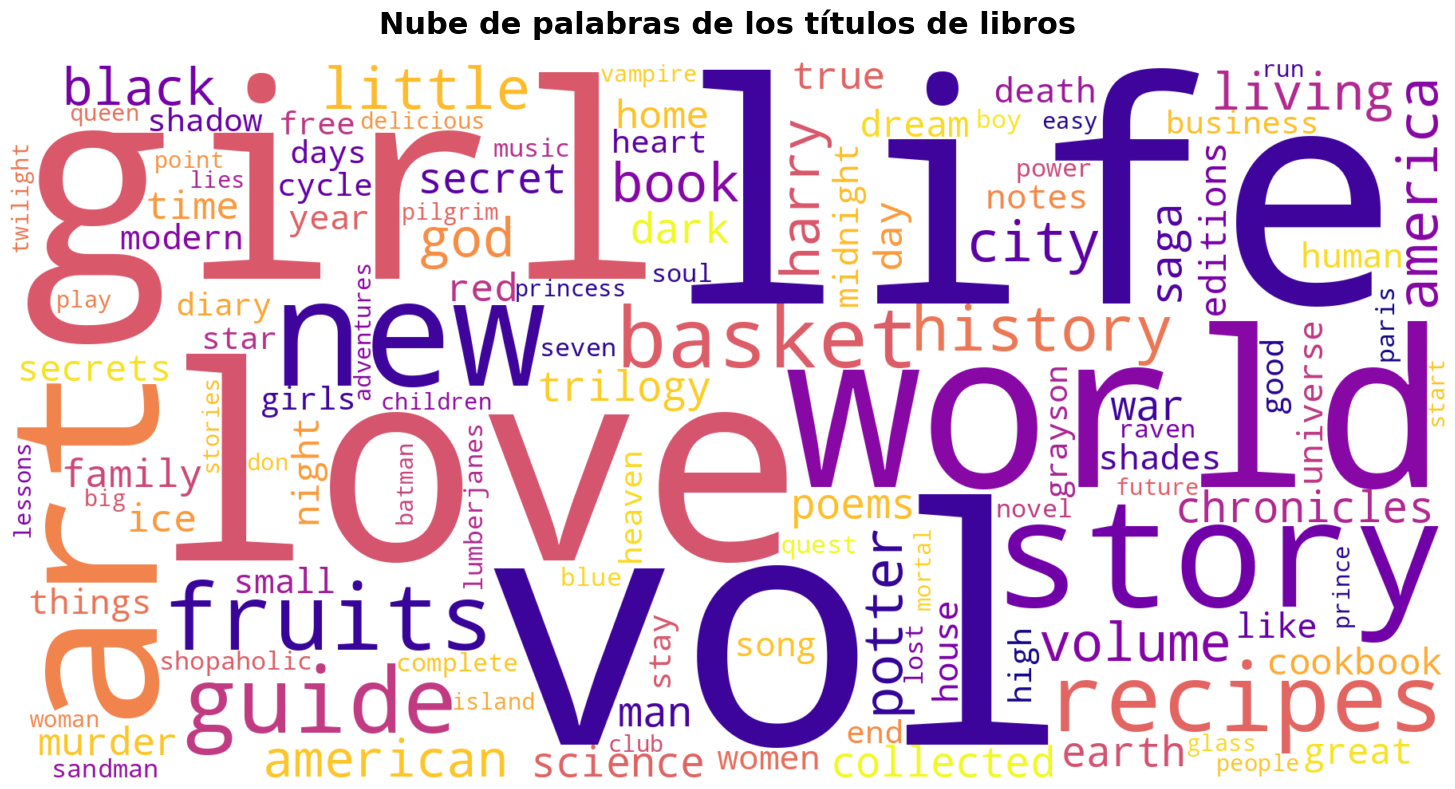

In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Diccionario de frecuencias
frecuencias = dict(zip(count["ngram"], count["frecuencia"]))

wordcloud = WordCloud(
    width=1800,
    height=900,
    background_color="white",   # fondo limpio
    colormap="plasma",          # prueba también: viridis, magma, cividis
    max_words=120,
    contour_width=2,
    contour_color="black",
    prefer_horizontal=0.85,
    relative_scaling=0.5,
    collocations=False,
    random_state=42
).generate_from_frequencies(frecuencias)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(
    "Nube de palabras de los títulos de libros",
    fontsize=22,
    fontweight="bold",
    pad=20
)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
## d) MATRIZ DE TERM FREQUENCY (TF) + AÑADIR PRECIO
# ------------------------------------------------------------
### Aquí conviene trabajar con unigramas

In [5]:

vectorizer_tf = CountVectorizer(ngram_range=(1, 1))
X_tf = vectorizer_tf.fit_transform(datos_limpios["title_clean"])

tf = pd.DataFrame(
    X_tf.toarray(),
    columns=vectorizer_tf.get_feature_names_out()
)

tf.insert(0, "title", datos_limpios["title"])
tf["price"] = datos_limpios["price"]

print("\nMatriz TF con precio:")
print(tf.head())

tf.to_csv("matriz_tf_con_precios.csv", index=False)


Matriz TF con precio:
                                   title  abraham  abstract  absurd  \
0                   A Light in the Attic        0         0       0   
1                     Tipping the Velvet        0         0       0   
2                             Soumission        0         0       0   
3                          Sharp Objects        0         0       0   
4  Sapiens: A Brief History of Humankind        0         0       0   

   abundance  academy  acceptance  according  account  accra  ...  yolks  \
0          0        0           0          0        0      0  ...      0   
1          0        0           0          0        0      0  ...      0   
2          0        0           0          0        0      0  ...      0   
3          0        0           0          0        0      0  ...      0   
4          0        0           0          0        0      0  ...      0   

   york  young  zealot  zen  zero  zombie  zombies  zucchini  price  
0     0      0       0 

# ------------------------------------------------------------
## e) ELEGIR 10 PALABRAS Y REEMPLAZAR FRECUENCIA POR 1/0
### Luego calcular el precio promedio cuando aparece y cuando no aparece
# ------------------------------------------------------------

### Elegimos automáticamente las 10 palabras más frecuentes

In [6]:

frecuencia_unigramas = tf.drop(columns=["title", "price"]).sum().sort_values(ascending=False)
palabras_elegidas = frecuencia_unigramas.head(10).index.tolist()

print("\n10 palabras elegidas:")
print(palabras_elegidas)

# Convertir esas columnas a binarias: 1 si aparece al menos una vez, 0 si no aparece
tf_binaria = tf.copy()
for palabra in palabras_elegidas:
    tf_binaria[palabra] = (tf_binaria[palabra] > 0).astype(int)

# Base larga para agrupar
analisis_palabras = tf_binaria.melt(
    id_vars=["title", "price"],
    value_vars=palabras_elegidas,
    var_name="palabra",
    value_name="aparece"
)

# Precio promedio según aparición
resumen_precios = (
    analisis_palabras
    .groupby(["palabra", "aparece"], as_index=False)["price"]
    .mean()
)

resumen_precios["aparece_label"] = resumen_precios["aparece"].map({
    0: "No aparece",
    1: "Sí aparece"
})

print("\nPrecio promedio según aparición de la palabra:")
print(resumen_precios.sort_values(["palabra", "aparece"]))

resumen_precios.to_csv("precio_promedio_por_palabra.csv", index=False)


10 palabras elegidas:
['vol', 'life', 'girl', 'love', 'world', 'art', 'story', 'new', 'recipes', 'guide']

Precio promedio según aparición de la palabra:
    palabra  aparece      price aparece_label
0       art        0  35.068161    No aparece
1       art        1  35.172381    Sí aparece
2      girl        0  34.979579    No aparece
3      girl        1  38.341481    Sí aparece
4     guide        0  35.040213    No aparece
5     guide        1  37.192857    Sí aparece
6      life        0  35.136459    No aparece
7      life        1  33.349730    Sí aparece
8      love        0  35.007041    No aparece
9      love        1  37.117333    Sí aparece
10      new        0  35.116263    No aparece
11      new        1  32.565556    Sí aparece
12  recipes        0  35.156033    No aparece
13  recipes        1  30.115882    Sí aparece
14    story        0  35.010561    No aparece
15    story        1  38.157368    Sí aparece
16      vol        0  35.045110    No aparece
17      vol      

# ------------------------------------------------------------
## f) GRÁFICO DE BARRAS
### Eje Y: palabra
### Eje X: valor del libro
### Color: si aparece o no aparece
# ------------------------------------------------------------

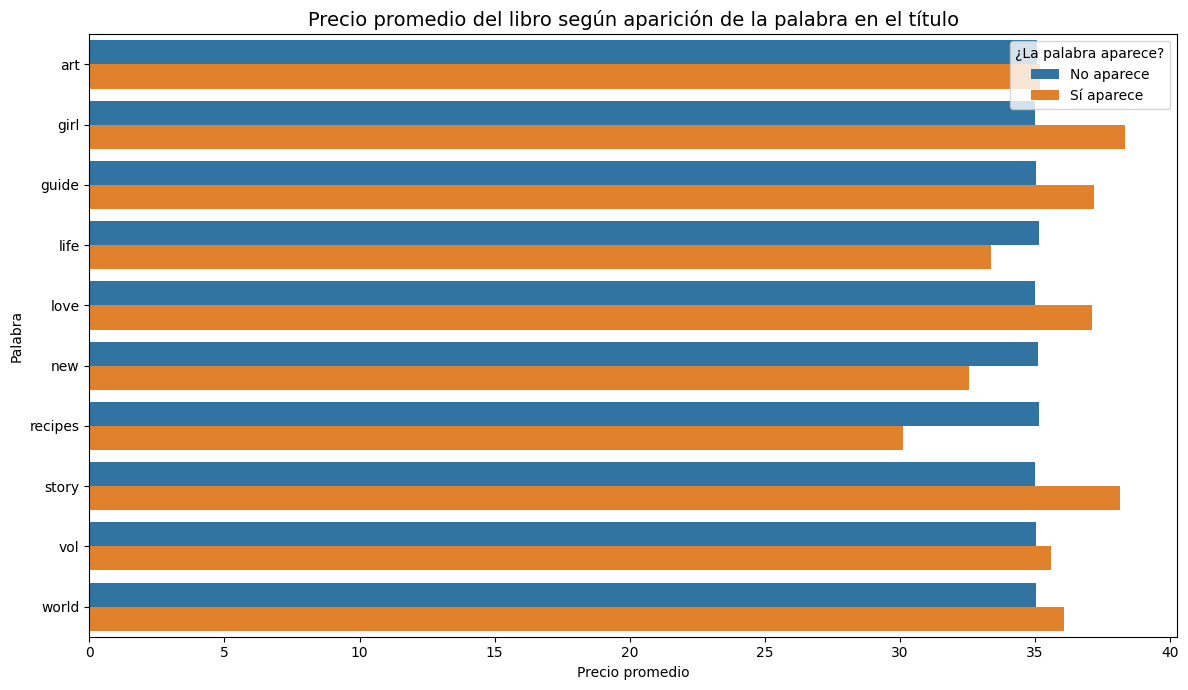

In [7]:

plt.figure(figsize=(12, 7))
sns.barplot(
    data=resumen_precios,
    y="palabra",
    x="price",
    hue="aparece_label"
)

plt.title("Precio promedio del libro según aparición de la palabra en el título", fontsize=14)
plt.xlabel("Precio promedio")
plt.ylabel("Palabra")
plt.legend(title="¿La palabra aparece?")
plt.tight_layout()
plt.show()

In [8]:
pivot_resumen = resumen_precios.pivot(index="palabra", columns="aparece_label", values="price")
pivot_resumen["diferencia"] = pivot_resumen["Sí aparece"] - pivot_resumen["No aparece"]
pivot_resumen = pivot_resumen.sort_values("diferencia", ascending=False)

print("\nPalabras más asociadas positivamente con el precio:")
print(pivot_resumen)

print("\nLas palabras con diferencia positiva más alta son las que, en promedio,")
print("aparecen en títulos de libros más caros. Esto es una asociación descriptiva, no causal.")


Palabras más asociadas positivamente con el precio:
aparece_label  No aparece  Sí aparece  diferencia
palabra                                          
girl            34.979579   38.341481    3.361903
story           35.010561   38.157368    3.146808
guide           35.040213   37.192857    2.152644
love            35.007041   37.117333    2.110292
world           35.047093   36.058261    1.011168
vol             35.045110   35.606000    0.560890
art             35.068161   35.172381    0.104220
life            35.136459   33.349730   -1.786729
new             35.116263   32.565556   -2.550707
recipes         35.156033   30.115882   -5.040150

Las palabras con diferencia positiva más alta son las que, en promedio,
aparecen en títulos de libros más caros. Esto es una asociación descriptiva, no causal.
